In [31]:
import pandas as pd
import numpy as np

In [32]:
df = pd.read_csv("/content/amazon_prime_titles.csv")

print("Shape:", df.shape)
df.head()

Shape: (9668, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary,"Pink breaks the mold once again, bringing her ..."
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...


In [33]:
df.info()
print("\nColumns:", df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       9668 non-null   object
 1   type          9668 non-null   object
 2   title         9668 non-null   object
 3   director      7585 non-null   object
 4   cast          8435 non-null   object
 5   country       672 non-null    object
 6   date_added    155 non-null    object
 7   release_year  9668 non-null   int64 
 8   rating        9331 non-null   object
 9   duration      9668 non-null   object
 10  listed_in     9668 non-null   object
 11  description   9668 non-null   object
dtypes: int64(1), object(11)
memory usage: 906.5+ KB

Columns: Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [35]:
df.columns = df.columns.str.strip()

if 'show_id' in df.columns:
    df.drop(['show_id'], axis=1, inplace=True)

df.fillna("Unknown", inplace=True)

print("After cleaning:", df.shape)

After cleaning: (9668, 11)


In [36]:
if 'duration' in df.columns:
    df['duration'] = df['duration'].astype(str).str.extract('(\d+)')
    df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
    df['duration'].fillna(0, inplace=True)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_11003/3472876995.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['duration'] = df['duration'].astype(str).str.extract('(\d+)')
/tmp/ipykernel_11003/3472876995.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['duration'].fillna(0, inplace=True)


In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print("Categorical columns encoded successfully!")
df.head()

Categorical columns encoded successfully!


,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,0,8008,1464,984,8,47,2014,24,113,267,1169
1,0,7488,1898,4639,26,47,2018,0,110,387,237
2,0,6796,2789,7384,60,47,2017,24,74,71,1723
3,0,6038,5017,2932,60,47,2014,24,69,321,6306
4,0,5225,1888,2760,51,47,1989,24,45,368,7235


In [39]:
print("Final Shape:", df.shape)

if len(df) < 10:
    print("ERROR: Dataset too small. Reload full dataset.")

Final Shape: (9668, 11)


In [42]:
X = df.drop('type', axis=1)
y = df['type']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

X shape: (9668, 10)
y shape: (9668,)

Target values:
type
0    7814
1    1854
Name: count, dtype: int64


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (7734, 10)
Test: (1934, 10)


In [44]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [45]:
y_pred = model.predict(X_test)

print("Predictions:", y_pred[:10])

Predictions: [1 1 0 0 0 0 0 1 1 0]


In [46]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9984488107549121

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1550
           1       0.99      1.00      1.00       384

    accuracy                           1.00      1934
   macro avg       1.00      1.00      1.00      1934
weighted avg       1.00      1.00      1.00      1934


Confusion Matrix:
 [[1548    2]
 [   1  383]]


In [47]:
import joblib

joblib.dump(model, "amazon_prime_model.pkl")

print("Model saved")

Model saved


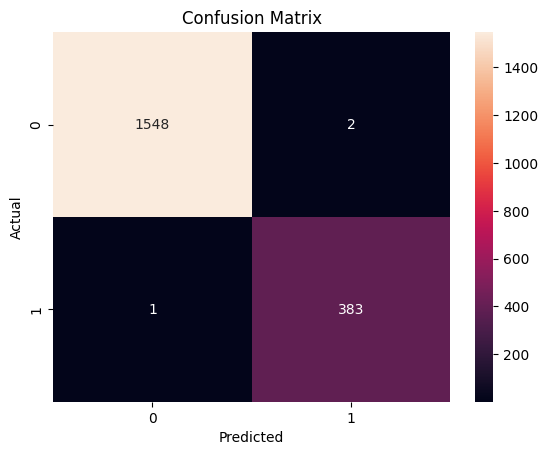

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [50]:
sample = X_test.iloc[0:1]
prediction = model.predict(sample)

print("Prediction:", prediction)

Prediction: [1]
